# From a fitted MMM to a PowerPoint readout

This notebook demonstrates the **slide-deck tool**: it turns a fitted Marketing
Mix Model into a filled copy of a branded `.pptx` template — headline KPIs, a
channel scorecard, ROI / next-dollar charts, and a per-channel deep-dive with
**breakthrough / optimal / saturation** spend zones.

The tool is built in **four layers**, and we walk them in order:

| # | layer | module | AI? |
|---|---|---|---|
| 1 | **spend zones** — ROI(spend) & **marginal ROI**(spend) + zones on a break-even band | `reporting.helpers.compute_response_zones` | no |
| 2 | **deck engine** — every slide's numbers, tables, and charts, straight from the model | `reporting.deck.build_deck` | no |
| 3 | **insight layer** — one insight per channel slide + a synthesized headline | `agents.deck_insights.generate_deck_insights` | **yes** |
| 4 | **template builder** — fills the `.pptx` template with the model's numbers/charts + the insights | `reporting.deck.builder.build_pptx` | no |

Two design rules the tool follows, both visible below:

* **Numbers and graphs come from model code, never from the LLM** — only the
  *prose insights* are AI-written, and each is grounded in its slide's
  deterministic facts.
* **The breakthrough / optimal / saturation ranges are defined on ROI and
  marginal ROI**, not on percent of maximum response.

One thing to keep straight: layer 4 (`build_pptx`) re-derives the numbers and
re-renders the charts **from the model itself** — it does not consume the `Deck`
object from layer 2. Layer 2's role is to produce the deterministic per-slide
*facts* that ground the AI insights; the resulting `insights` dict is the only
thing threaded from the AI layer into the builder.

> Source: `reporting/helpers/saturation.py`, `reporting/deck/` (engine, charts,
> builder), `agents/deck_insights.py`. Fired from chat via the
> `generate_slide_deck` tool and from the UI via `POST /projects/{id}/generate-deck`.

In [1]:
import warnings, logging
warnings.filterwarnings("ignore")
# Quiet the noise so the demo's tables/prints aren't buried: PyMC's posterior-
# predictive sampling (run inside the deck extractor) logs "Sampling: [y_obs]"
# from child loggers, and mmm_framework logs via loguru.
for _n in ("pymc", "pymc.sampling", "pymc.sampling.forward", "pytensor"):
    logging.getLogger(_n).setLevel(logging.ERROR)
from loguru import logger as _loguru
_loguru.disable("mmm_framework")

import numpy as np, pandas as pd
from IPython.display import Image, display

from mmm_framework.config import ModelConfig
from mmm_framework.model import BayesianMMM, TrendConfig
from mmm_framework.model.trend_config import TrendType
from mmm_framework.synth import dgp

# A small, real fit on the "realistic" synthetic world (7 channels). NUTS, a
# couple of chains — enough to drive the deck; this is the only slow cell. The
# divergence / r-hat warnings are expected from this deliberately tiny demo fit
# (300 draws, 2 chains) and don't affect the deck mechanics we're showing.
panel = dgp.build("realistic", seed=7, n_weeks=104).panel()
mmm = BayesianMMM(panel, ModelConfig(use_parametric_adstock=True),
                  TrendConfig(type=TrendType.LINEAR))
mmm.fit(draws=300, tune=600, chains=2, target_accept=0.9, random_seed=7, progressbar=False)
print("fitted channels:", mmm.channel_names)

There were 2 divergences after tuning. Increase `target_accept` or reparameterize.


We recommend running at least 4 chains for robust computation of convergence diagnostics


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


fitted channels: ['TV', 'Search', 'Social', 'Display', 'Video', 'Radio', 'Print']


## 1 · Spend zones on ROI & marginal ROI

`compute_response_zones` returns, per channel, the **response**, the **average
ROI**, and the **marginal ROI** across a spend grid (all with posterior credible
intervals), plus the **breakthrough / optimal / saturation** zones. The zones are
bands on *marginal ROI* relative to a break-even target:

* **optimal** — spend where marginal ROI ≈ break-even (the profit-maximizing point),
* **breakthrough** — marginal ROI well above break-even (under-invested → spend more),
* **saturation** — marginal ROI below break-even (over-invested → reallocate).

For a revenue KPI the break-even is `1.0` (or `1/margin`). This synthetic KPI is
an index, not dollars, so we set the break-even at the **portfolio-median marginal
ROI** purely so more than one zone is visible in the demo (you'll see
*saturation* and *optimal* channels). `optimal_spend` is `None` for a channel
whose marginal-ROI curve never crosses break-even in the modeled range (here:
sits entirely below it → "reduce toward the minimum").

In [2]:
from mmm_framework.reporting.helpers import compute_response_zones

# pick a break-even inside the data's mROI range so the zones are illustrative
probe = compute_response_zones(mmm, break_even=1.0, hdi_prob=0.8)
break_even = float(np.median([z.current_mroi for z in probe.values()])) or 1.0
zones = compute_response_zones(mmm, break_even=break_even, hdi_prob=0.8)

rows = [{
    "channel": ch,
    "current ROI": round(z.current_roi, 2),
    "ROI 80% HDI": f"[{z.current_roi_hdi[0]:.2f}, {z.current_roi_hdi[1]:.2f}]",
    "current mROI": round(z.current_mroi, 2),
    "mROI 80% HDI": f"[{z.current_mroi_hdi[0]:.2f}, {z.current_mroi_hdi[1]:.2f}]",
    "zone": z.current_zone,
    "action": z.recommendation,
    "optimal spend": None if z.optimal_spend is None else round(z.optimal_spend, 1),
} for ch, z in zones.items()]
zone_tbl = pd.DataFrame(rows).set_index("channel")
print(f"break-even mROI used for the demo: {break_even:.2f}")
display(zone_tbl)

# every channel is classified into exactly one zone with a directional action,
# and the demo break-even produces more than one zone (not a vacuous check).
assert set(zone_tbl["zone"]) <= {"breakthrough", "optimal", "saturation"}
assert set(zone_tbl["action"]) <= {"increase", "hold", "reduce"}
assert len(set(zone_tbl["zone"])) >= 2, "expected multiple zones in the demo"

break-even mROI used for the demo: 0.23


,current ROI,ROI 80% HDI,current mROI,mROI 80% HDI,zone,action,optimal spend
channel,,,,,,,
TV,0.15,"[0.05, 0.22]",0.14,"[0.05, 0.20]",saturation,reduce,NaN
Search,0.16,"[0.10, 0.20]",0.15,"[0.09, 0.19]",saturation,reduce,NaN
Social,0.24,"[0.13, 0.33]",0.23,"[0.13, 0.32]",optimal,hold,38.9
Display,0.26,"[0.09, 0.34]",0.25,"[0.10, 0.34]",optimal,hold,57.9
Video,0.15,"[0.00, 0.24]",0.14,"[0.00, 0.23]",saturation,reduce,NaN
Radio,0.26,"[0.00, 0.40]",0.25,"[0.00, 0.38]",optimal,hold,32.8
Print,0.44,"[0.00, 0.63]",0.41,"[0.00, 0.61]",breakthrough,increase,NaN


The same per-channel object renders the **centerpiece chart**: the response curve
with the three zones shaded, the ROI and marginal-ROI overlay, and the
current/optimal spend markers (the optimal marker shows only where an in-range
optimum exists). This exact chart is what lands on each channel's deep-dive slide.

channel: Social  (zone: optimal)


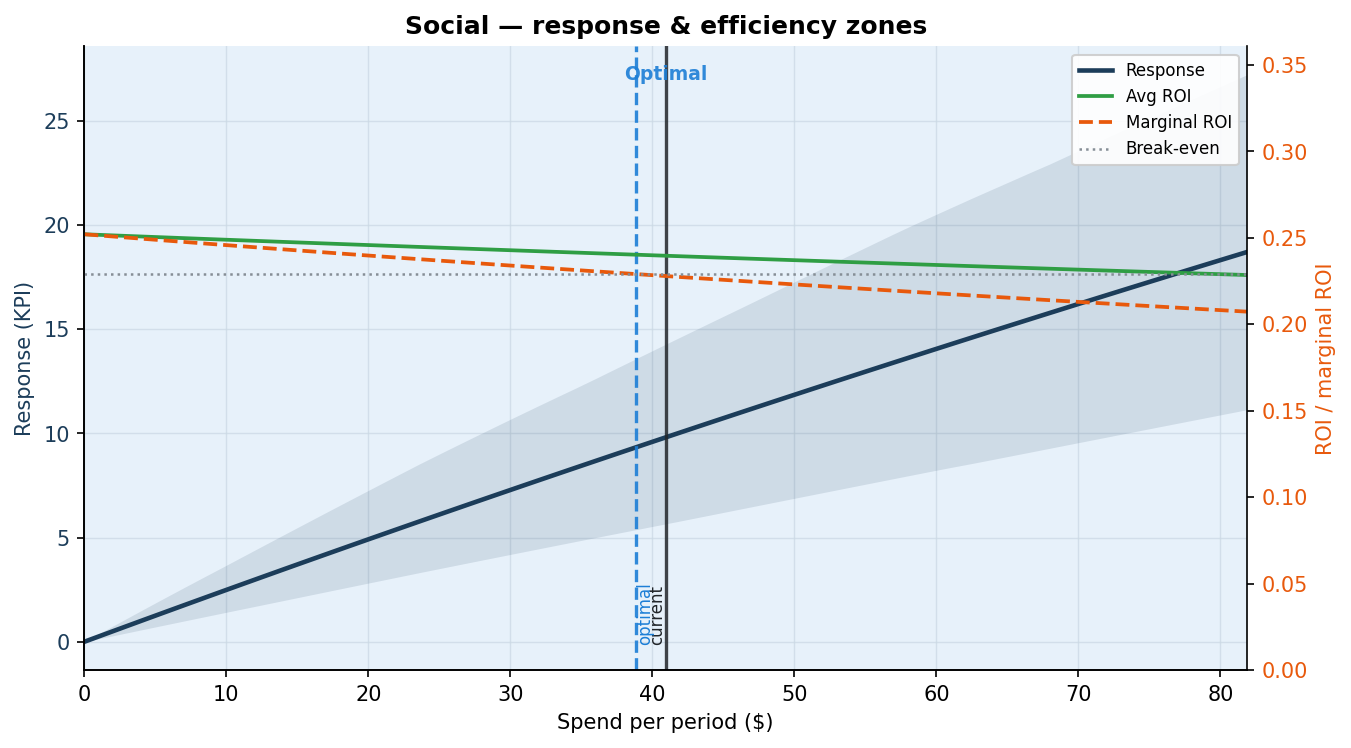

In [3]:
from mmm_framework.reporting.deck import charts

# show a channel that HAS an in-range optimum, so the 'optimal' marker is visible
ch0 = next((c for c, z in zones.items() if z.optimal_spend is not None), next(iter(zones)))
png = charts.saturation_zones_png(zones[ch0], currency="$")
assert png[:8] == b"\x89PNG\r\n\x1a\n"  # a valid PNG
print(f"channel: {ch0}  (zone: {zones[ch0].current_zone})")
display(Image(data=png))

The **marginal ROI** ("what the next dollar returns") is its own headline view in
the deck — a forest plot of each channel's current marginal ROI with its 80%
credible interval, against the break-even line. It's the chart on the deck's
"THE NEXT DOLLAR" slide.

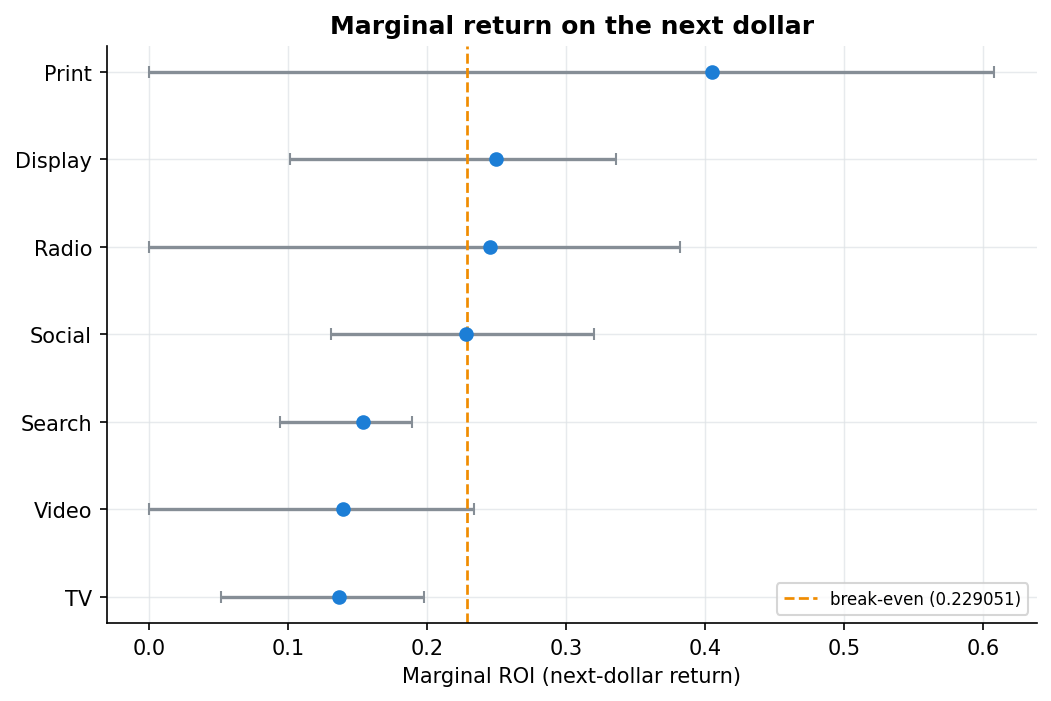

In [4]:
mroi_dict = {ch: {"mean": z.current_mroi,
                  "lower": z.current_mroi_hdi[0], "upper": z.current_mroi_hdi[1]}
             for ch, z in zones.items()}
display(Image(data=charts.roi_forest_png(
    mroi_dict, break_even=break_even,
    title="Marginal return on the next dollar",
    xlabel="Marginal ROI (next-dollar return)")))

## 2 · The deterministic deck engine

`build_deck` assembles the whole deck **from the model, with no AI** — an ordered
list of `Slide`s, each carrying its numbers (`metrics`), tables, a chart image,
and a deterministic `notes` string. It also marks deck-level **summary** slides
(title, executive summary, reallocation — `kind="optimization"`) whose narrative
is later synthesized from the *whole* deck. `margin` would set a profit-maximizing
break-even; here we pass the same demo break-even.

In [5]:
from mmm_framework.reporting.deck import build_deck

deck = build_deck(mmm, client="Acme Corp", kpi_name="Revenue", currency="$",
                  break_even=break_even)
overview = pd.DataFrame([
    {"#": i, "kind": s.kind, "title": s.title, "summary?": s.is_summary,
     "has chart": s.chart_png is not None, "insight": s.insight}
    for i, s in enumerate(deck.slides)
])
display(overview)

# the deck has the expected spine, and NO AI has run yet (insight is None)
kinds = [s.kind for s in deck.slides]
for k in ("title", "executive_summary", "channel_roi", "saturation", "optimization", "methodology"):
    assert k in kinds, k
assert all(s.insight is None for s in deck.slides)
print(f"{len(deck.slides)} logical slides; "
      f"{sum(s.is_summary for s in deck.slides)} summary slides; "
      f"{sum(s.chart_png is not None for s in deck.slides)} charts")

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

,#,kind,title,summary?,has chart,insight
0,0,title,Acme Corp — Marketing Mix Modeling Results,True,False,None
1,1,executive_summary,Executive summary,True,False,None
2,2,model_fit,Model fit,False,True,None
3,3,decomposition,KPI decomposition,False,True,None
4,4,channel_roi,Return on investment by channel,False,True,None
5,5,saturation,TV: spend efficiency & headroom,False,True,None
6,6,saturation,Search: spend efficiency & headroom,False,True,None
7,7,saturation,Social: spend efficiency & headroom,False,True,None
8,8,saturation,Display: spend efficiency & headroom,False,True,None
9,9,saturation,Video: spend efficiency & headroom,False,True,None


14 logical slides; 3 summary slides; 11 charts


Each slide is self-describing. Here is one channel deep-dive's deterministic
content — the numbers that fill its metric cards, and the `notes` string that the
AI insight is written *from* (so the prose can never invent a number):

TITLE : TV: spend efficiency & headroom
BULLETS:
   • Current spend sits in the Saturation (over-invested) zone.
   • Marginal ROI at current spend: 0.14x (break-even 0.229051).

NOTES (insight context):
   Saturation/headroom for TV. It is in the 'saturation' zone with current marginal ROI 0.14 vs a 0.229051 break-even; the deterministic recommendation is to reduce. Turn this into a specific, quantified spend recommendation for this channel.

ZONE METRICS: {'channel': 'TV', 'current_zone': 'saturation', 'recommendation': 'reduce', 'current_mroi': 0.13576853376105202, 'optimal_spend': None}


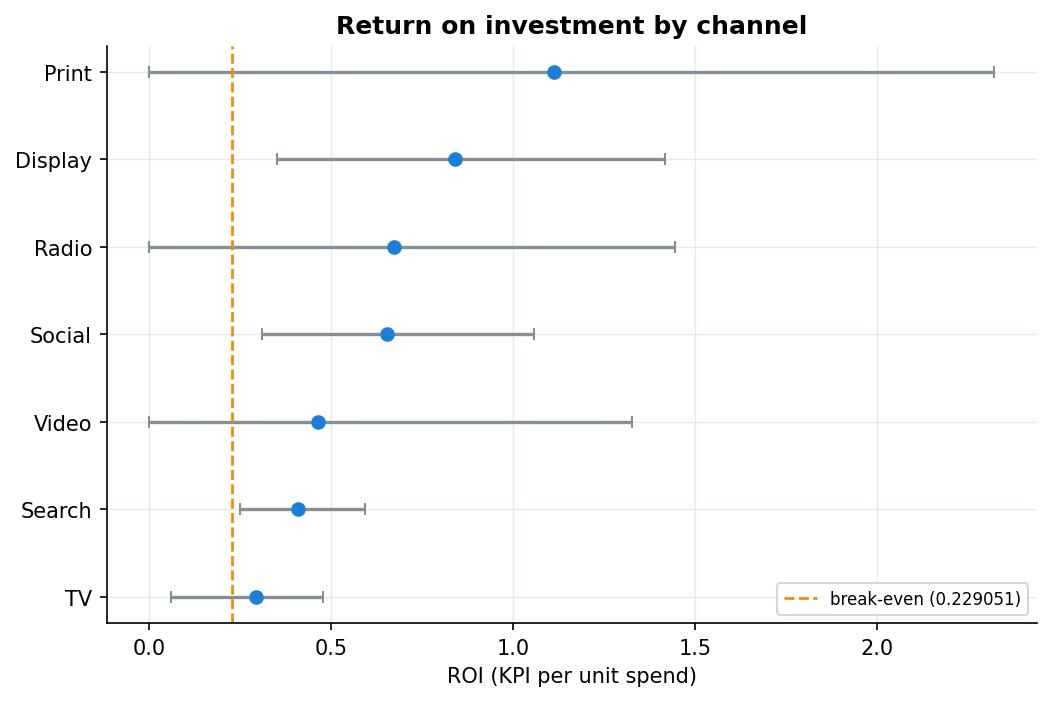

In [6]:
sat = next(s for s in deck.slides if s.kind == "saturation")
print("TITLE :", sat.title)
print("BULLETS:")
for b in sat.bullets:
    print("   •", b)
print("\nNOTES (insight context):\n  ", sat.notes)
print("\nZONE METRICS:", {k: sat.metrics["zones"][k] for k in
      ("channel", "current_zone", "recommendation", "current_mroi", "optimal_spend")})

# render the deck's ROI-forest chart inline
display(Image(data=next(s for s in deck.slides if s.kind == "channel_roi").chart_png))

## 3 · The agentic insight layer

`generate_deck_insights` turns each slide's deterministic `notes` into prose:

* **one grounded LLM call per channel deep-dive** — its narrative, from its zone
  facts;
* **one synthesis call over *all* slide facts** — the report headline (the single
  biggest finding + the top reallocation move).

These are direct, grounded calls (a system prompt + the facts), not a full agent
thread. Below we use a tiny **fake** LLM so the notebook is deterministic; in
production you pass the configured model (`from mmm_framework.agents.llm import
build_llm; build_llm()`), which is what the chat agent's `generate_slide_deck`
tool does — the API job builds the same model from the request headers via
`get_llm(...)`.

In [7]:
from mmm_framework.agents.deck_insights import generate_deck_insights, slide_key, light_metrics

# the model-op `slide_deck_notes` produces this light per-slide list; we build it
# here directly from the deck object.
notes = [{"key": slide_key(s), "kind": s.kind, "title": s.title,
          "notes": s.notes, "is_summary": s.is_summary, "metrics": light_metrics(s)}
         for s in deck.slides]

class _FakeResp:
    def __init__(self, c): self.content = c
class _FakeLLM:
    def __init__(self): self.calls = 0
    def invoke(self, messages):
        self.calls += 1
        first = messages[-1].content.splitlines()[0]   # echo the slide to show grounding
        return _FakeResp(f"[demo insight #{self.calls}] {first} — act on the marginal return.")

llm = _FakeLLM()
insights = generate_deck_insights(notes, llm)
print(f"LLM calls: {llm.calls}  (one per channel deep-dive + one synthesis)")
print("insight keys:", sorted(insights))
print("\nheadline (synthesized):\n  ", insights.get("headline", "—"))

# one insight per channel deep-dive, plus the synthesized headline
n_channels = sum(1 for s in deck.slides if s.kind == "saturation")
assert "headline" in insights
assert sum(1 for k in insights if k.startswith("channel:")) == n_channels

LLM calls: 8  (one per channel deep-dive + one synthesis)
insight keys: ['channel:Display', 'channel:Print', 'channel:Radio', 'channel:Search', 'channel:Social', 'channel:TV', 'channel:Video', 'headline']

headline (synthesized):
   [demo insight #8] The deck's slide facts: — act on the marginal return.


The insight layer is **best-effort**: if the LLM is unreachable it returns no
narrative (and short-circuits on the first failure rather than retrying every
slide), so the deck still renders — just without prose. Here's that path, with a
deliberately failing LLM:

In [8]:
class _RaisingLLM:
    def invoke(self, messages):
        raise RuntimeError("LLM endpoint unreachable")

degraded = generate_deck_insights(notes, _RaisingLLM())
print("insights when the LLM is down:", degraded)   # {}
assert degraded == {}    # no narrative, no headline — and no exception

insights when the LLM is down: {}


## 4 · Fill the template → `.pptx`

`build_pptx` opens the bundled template (`default_template_path()`), re-derives
the numbers and charts from the model, fills the template's slides by stable
label text + geometry, fills one channel deep-dive per channel, and drops in the
AI `insights`. The bundled template is a finished **24-slide** readout; the
builder fills the slides that correspond to the engine's logical slides (one
deep-dive per model channel) — for a model with fewer channels than the template
has deep-dive slots, the extras are deleted, so the physical slide count can be
below 24. It writes a real `.pptx` and returns its bytes.

In [9]:
import tempfile, os
from mmm_framework.reporting.deck.builder import build_pptx, default_template_path

out = os.path.join(tempfile.mkdtemp(), "acme_mmm_readout.pptx")
data = build_pptx(mmm, out_path=out, insights=insights, client="Acme Corp",
                  kpi_name="Revenue", currency="$", break_even=break_even, hdi_prob=0.8)
print("template :", default_template_path().name)
print("wrote    :", out, f"({len(data)/1e6:.1f} MB)")
assert os.path.getsize(out) > 10000

# graceful degradation, end to end: no insights -> deck still renders fully
out_nonarr = os.path.join(tempfile.mkdtemp(), "no_narrative.pptx")
build_pptx(mmm, out_path=out_nonarr, insights={}, client="Acme Corp",
           kpi_name="Revenue", currency="$", break_even=break_even, hdi_prob=0.8)
assert os.path.getsize(out_nonarr) > 10000
print("no-narrative deck still renders:", os.path.getsize(out_nonarr), "bytes")

Output()

Output()

Output()

Output()

Output()

...

Output()

Output()

Output()

Output()

no-narrative deck still renders: 4969230 bytes


Re-open the generated deck with `python-pptx` to confirm what landed: the headline
KPI cards (with 80% ranges, computed from posterior portfolio-contribution draws),
the scorecard naming every channel, the "next dollar" marginal-ROI slide, one
deep-dive per channel, and the AI insight text.

The scorecard and deep-dives also carry a **READ / ACTION** label
(*Confidently profitable → Scale*, *High upside, unproven → Test*, *Near
break-even → Hold*, *Below break-even → Reduce*). That's a complementary
classification from the **average-ROI** credible interval vs break-even — distinct
from the zone `recommendation` (increase/hold/reduce), which comes from the
**marginal-ROI** band.

In [10]:
from pptx import Presentation
prs = Presentation(out)

def texts(s):
    return [sh.text_frame.text for sh in s.shapes if sh.has_text_frame and sh.text_frame.text.strip()]
def has(s, label):
    return any(t.strip().lower() == label.lower() for t in texts(s))

channels = set(mmm.channel_names)
deep = [s for s in prs.slides if has(s, "RETURN / $1") and has(s, "CARRYOVER HALF-LIFE")]
all_text = " ".join(t for s in prs.slides for t in texts(s))
head = next(s for s in prs.slides if has(s, "THE HEADLINE"))

print(f"physical slides in deck : {len(prs.slides)}")
print(f"per-channel deep-dives  : {len(deep)}  (one per model channel; model has {len(channels)})")
print(f"headline 80% ranges     : {'80% range' in ' '.join(texts(head))}")
print(f"scorecard names all ch  : {channels.issubset(set(t for s in prs.slides for t in texts(s)))}")
print(f"'THE NEXT DOLLAR' slide  : {any(has(s, 'THE NEXT DOLLAR') for s in prs.slides)}")
print(f"AI insight text present : {'demo insight' in all_text}")

assert len(deep) == len(channels)                    # one deep-dive per channel
for kpi in ("MARKETING-ATTRIBUTED REVENUE", "SHARE OF TOTAL REVENUE", "BLENDED RETURN PER $1"):
    assert any(t.strip().lower() == kpi.lower() for t in texts(head)), kpi
assert "80% range" in " ".join(texts(head))          # KPI cards filled with ranges
assert any(has(s, "THE NEXT DOLLAR") for s in prs.slides)  # marginal-ROI slide present
assert "demo insight" in all_text                    # insights landed

physical slides in deck : 24


per-channel deep-dives  : 7  (one per model channel; model has 7)
headline 80% ranges     : True
scorecard names all ch  : True
'THE NEXT DOLLAR' slide  : True
AI insight text present : True


## 5 · The same thing, from chat and the UI

Everything above is wrapped so a user never has to touch the API:

* **Chat agent** — the `generate_slide_deck` tool runs *outline → insights →
  render* and hands back a download link. Ask the Oracle: *"make a client slide
  deck."* (`agents/tools.py`, model-ops `slide_deck_notes` / `render_slide_deck`.)
* **UI** — the Results-tab **"Generate slide deck"** button starts a non-blocking
  job and polls it:

  ```
  POST /projects/{id}/generate-deck            -> { job_id }
  GET  /projects/{id}/generate-deck/{job_id}   -> { status, stage, result|error }
  GET  /projects/{id}/generate-deck/{job_id}/download   -> the .pptx
  ```

  The job runs the deterministic outline, the LLM insight + synthesis pass, then
  the render — model work runs in a worker thread, the insight pass is an LLM call,
  all within the API process. A slow/unavailable LLM degrades to a deck with no
  narrative rather than failing (the path shown above).

* **Your own template** — `build_pptx(..., template_path=...)` accepts any branded
  `.pptx`, and `default_template_path()` honours the `MMM_DECK_TEMPLATE` env
  override, so a client's deck design drops straight in.

## What to remember

1. **Model code makes the numbers and charts; AI only writes the prose** — and
   each insight is grounded in its slide's deterministic facts.
2. **Spend zones are ROI/mROI break-even bands**, not percent of response — the
   optimal point is where the next dollar breaks even.
3. **Per-slide insight + whole-deck synthesis** — the headline is written from
   the entire deck's facts, the channel narratives from each slide's.
4. **It fills *your* template** — fonts, layout, and branding are preserved; the
   builder fills shapes and swaps charts, one deep-dive per channel.

> Run it for real: fit a model (e.g. `uv run python examples/ex_model_workflow.py`),
> then ask the chat agent for a slide deck or `POST /projects/{id}/generate-deck`.
> Tests: `tests/test_slide_deck_generation.py`, `tests/reporting/test_deck_*.py`.